In [1]:
#Importacion de Librerias
import numpy as np
import pandas as pd
import math as m
import time as t
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Esto me sirve para realizar el WebScarping para la imputacion de informacion#
import requests
import random
import os
from bs4 import BeautifulSoup
import json


**Preguntas que responder**
1. Que tipo de contenido esta disponible en diferentes paises?
2. Cuanto es el numero de peliculas o tv shows que slieron han cambiado en los ultimos years?
3. Comparacion de las series vs peliculas
4. Cuando es el mejor momento para lanzar una serie de television?
5. Analisis de actores y directores de diferentes tv shows y peliculas.
6. Tiene netflix mas enfoque en los tvshows o en las peliculas en los recientes years
7. Que tipo de contenido esta disponible en diferentes paises?

**Notas:**
Como se puede observar para algunos procesos los datos que mas se ocupan son los paises, fechas, actores, directores.
Por lo que si no existen se necesitan imputar esos datos, por lo que usaremos el webscrapping para ello.

In [2]:
# Obtencion de Datos
# --- CONFIGURACIÓN ---
ARCHIVO_COPIA = "Copia_DataBase.csv"
COLUMNA_URL = "url_rotten"

## LOCAL
def load_data_local(ubicacion):
    try:
        df = pd.read_csv(ubicacion)
        return df
    except Exception as e:
        print(f"Error al cargar la B.D.: {e}")
        return None

In [3]:
def extraer_rotten_tomatoes(titulo, session):
    try:
        # 1. Buscar en Rotten Tomatoes
        search_url = f"https://www.rottentomatoes.com/search?search={titulo.replace(' ', '%20')}"
        res_search = session.get(search_url, timeout=10)
        soup_search = BeautifulSoup(res_search.text, 'html.parser')
        
        # Buscar el primer link de película o TV show
        # RT usa componentes personalizados como <search-page-media-row>
        resultado = soup_search.find('a', {'data-qa': 'info-name'})
        if not resultado:
            return None
            
        url_final = resultado['href']
        res_page = session.get(url_final, timeout=10)
        soup_page = BeautifulSoup(res_page.text, 'html.parser')
        
        # 2. Extraer Director de la sección Movie Info
        director = "N/A"
        dir_label = soup_page.find('b', string=lambda s: s and 'Director' in s)
        if dir_label:
            # El nombre está en el siguiente elemento <span> o <a>
            director = dir_label.find_next('span').text.strip()
            
        # 3. Extraer Cast (Primeros 3)
        cast_items = soup_page.find_all('p', {'data-qa': 'cast-crew-item-name'})
        cast_final = ", ".join([actor.text.strip() for actor in cast_items[:3]])
        print({
                "pais": "",
                "director": director,
                "cast": cast_final
            })
        return {
            "pais": "", # RT rara vez especifica país si no es extranjero
            "director": director,
            "cast": cast_final
        }
    except Exception as e:
        return None

In [4]:
def extraer_imdb(titulo, session):
    try:
        search_url = f"https://www.imdb.com/find?q={titulo.replace(' ', '+')}"
        res_search = session.get(search_url, timeout=10)
        soup_search = BeautifulSoup(res_search.text, 'html.parser')

        resultado = soup_search.find('a', href=lambda h: h and '/title/tt' in h)
        if not resultado:
            return None

        url_final = f"https://www.imdb.com{resultado['href'].split('?')[0]}"
        res_page = session.get(url_final, timeout=10)
        soup_page = BeautifulSoup(res_page.text, 'html.parser')

        # Bloque JSON
        script_tag = soup_page.find('script', type='application/ld+json')
        data = json.loads(script_tag.string) if script_tag else {}

        # Director
        directores = data.get("director", []) or data.get("creator", [])
        if isinstance(directores, list):
            director_final = ", ".join([d.get("name") for d in directores if "name" in d])
        else:
            director_final = directores.get("name") if directores else ""

        # Cast
        reparto = data.get("actor", [])
        cast_final = ", ".join([a.get("name") for a in reparto[:3]])

        # País (buscar en bloque de detalles)
        pais_final = ""
        detalles = soup_page.find("li", attrs={"data-testid": "title-details-origin"})
        if detalles:
            # Extraer solo los nombres de los países
            enlaces_paises = detalles.find_all("a")
            paises = [a.get_text(strip=True) for a in enlaces_paises]
            pais_final = ", ".join(paises)

        return {
            "pais": pais_final,
            "director": director_final,
            "cast": cast_final
        }

    except Exception as e:
        print("Error en extraer_imdb:", e)
        return None

In [5]:
def Web_Scrapping_Pro(dataSet):
    if os.path.exists(ARCHIVO_COPIA):
        dataSet = pd.read_csv(ARCHIVO_COPIA)
    session = requests.Session()
    
    # Lista de navegadores para rotar
    headers_list = [
        {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/121.0.0.0'},
        {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) Safari/537.36'},
        {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) Firefox/122.0'}
    ]

    print('Empieza el proceso del WebScrapping!!')
    cont_sesion = 0
    for i, fila in dataSet.iterrows():
        # print(not pd.notna(fila['country'] !="" or fila['cast'] != "" or fila['director'] !=""))
        if not ((pd.isna(fila['country']) or fila['country'] == "") and (pd.isna(fila['cast']) or fila['cast'] == "") and (pd.isna(fila['director']) or fila['director'] == "")):
            continue


        titulo_busqueda = fila.get('title', '')
        print(titulo_busqueda)
        # print(fila.get('country',''))
        # print(fila.get('director',''))
        # print(fila.get('cast',''))
        session.headers.update(random.choice(headers_list))
        try:
            datos_extraidos = extraer_imdb(titulo_busqueda,session)
            # print('Primer datos:\n',datos_extraidos)
            if not datos_extraidos or all(v == "" for v in datos_extraidos.values()):
                t.sleep(2)
                datos_extraidos = extraer_rotten_tomatoes(titulo_busqueda,session)
                # print('Segunda vuelta datos:\n',datos_extraidos)
            if datos_extraidos:
                dataSet.at[i, 'country'] = datos_extraidos.get('pais', '')
                dataSet.at[i, 'director'] = datos_extraidos.get('director', '')
                dataSet.at[i, 'cast'] = datos_extraidos.get('cast', '')

                dataSet.to_csv(ARCHIVO_COPIA,index=False)
                cont_sesion += 1

            if cont_sesion % 50 == 0 and cont_sesion != 0:
                print("\n☕ Bloque de 50 completado. Descanso largo de 5 min para enfriar IP...")
                t.sleep(300) # 5 minutos
            else:
                # Pausa corta aleatoria entre películas (fundamental)
                espera = random.uniform(12, 20) 
                t.sleep(espera)
        except Exception as e:
            print(f"⚠️ Error en {titulo_busqueda}: {e}. Esperando 1 minuto...")
            t.sleep(60)
    print('Mision Cumplida')
    return dataSet


In [6]:
df = load_data_local(r"C:\Users\Isaia\Downloads\netflix_data.csv")  
# Web_Scrapping_Pro(df)

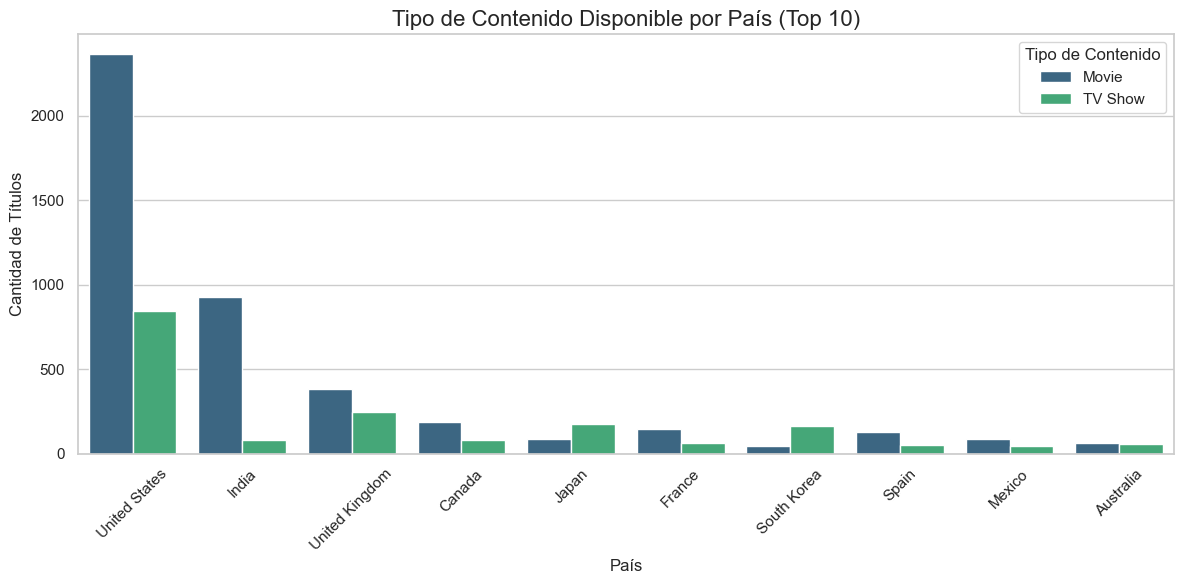

In [7]:
# Que tipo de contenido esta disponible en diferentes paises?#
def graficar_contenido_por_pais(df):
    # Realizamos una limpieza de los paises
    df['first_country'] = df['country'].str.split(',').str[0]
    
    # Seleccionamos los top 10 países con más títulos para no saturar la gráfica
    top_countries = df['first_country'].value_counts().nlargest(10).index
    df_top = df[df['first_country'].isin(top_countries)]
    
    # Configuramos el estilo de la gráfica
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Crear el gráfico de barras agrupadas
    ax = sns.countplot(
        data=df_top, 
        x='first_country', 
        hue='type', 
        order=top_countries,
        palette='viridis'
    )
    
    # Personalización
    plt.title('Tipo de Contenido Disponible por País (Top 10)', fontsize=16)
    plt.xlabel('País', fontsize=12)
    plt.ylabel('Cantidad de Títulos', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Tipo de Contenido')
    
    plt.tight_layout()
    plt.show()
# Uso
graficar_contenido_por_pais(df)

In [8]:
#Funcion para obtencion de maximo de la columna #
def get_max_value(values):
    max_val = None
    # if(len(values) > 0):
    for p in values:
        if max_val is None or (isinstance(p,(int,float)) and p > max_val):
            max_val = p
    return max_val

#Funcion para obtencion de minimos de la columna#
def get_min_value(values): 
    min_value = None
    # if(len(values) > 0):
    for p in values:
        if min_value is None or (isinstance(p,(int,float)) and p < min_value):
            min_value = p
    return min_value


In [9]:
def filtrar_Tipo(df, tipo):
    opciones = {1: 'Movie', 2: 'TV Show'}
    return df[df['type'] == opciones.get(tipo, 'Movie')]

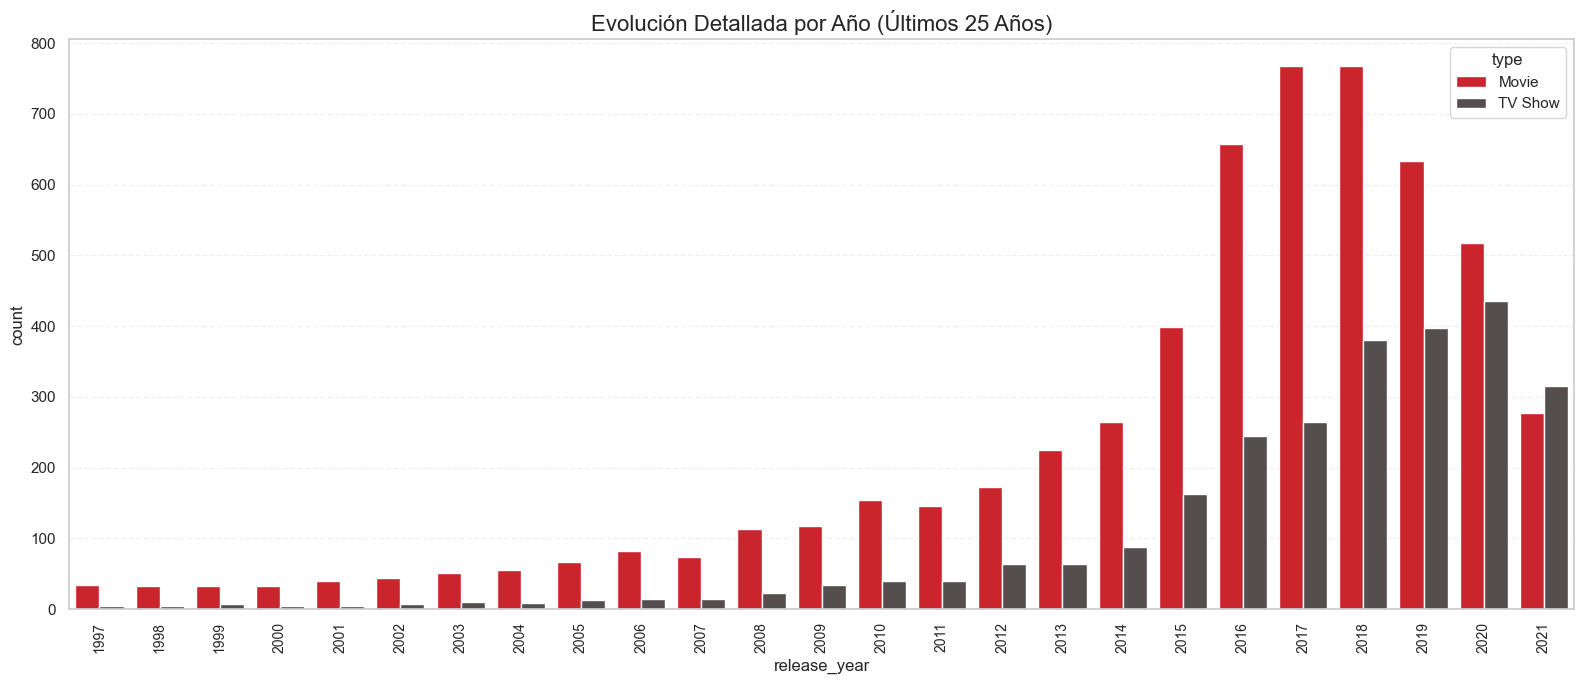

In [10]:
#  Cuanto es el numero de peliculas o tv shows que salieron han cambiado en los ultimos years? 20 - 30 #
def cant_salidas_years(df,diffyear):
     validYrMin_Mv = get_min_value((filtrar_Tipo(df, 1)['release_year']))
     validYrMin_Tv = get_min_value((filtrar_Tipo(df, 2)['release_year']))
     

     #Tv show#
     yearMax_tv = get_max_value(filtrar_Tipo(df, 1)['release_year'])
     yearMin_tv = yearMax_tv - diffyear
     # print(yearMin_tv)

     #Movies#
     yearMax_mv = get_max_value(filtrar_Tipo(df,2)['release_year'])
     # print(yearMax_mv)
     yearMin_mv = yearMax_mv - diffyear

     # Validacion para que el usuario ingrese fechas posibles#
     if(yearMin_mv < validYrMin_Mv or yearMin_tv < validYrMin_Tv ):
          print('Debe de ingresar un anio mayor a ',validYrMin_Tv,' o ',validYrMin_Mv)
          return

     df_mov = filtrar_Tipo(df,1)
     df_mov = df_mov[df_mov['release_year'] > yearMin_mv]

     df_tv= filtrar_Tipo(df,2)
     df_tv= df_tv[df_tv['release_year'] > yearMin_tv]
     
     # --- LÓGICA PARA GRAFICAR ---
     
     # Usando tu lógica de df_mov y df_tv ya filtrados
     df_grafica = pd.concat([df_mov, df_tv])
     # --- AJUSTE PARA MOSTRAR CADA AÑO ---

     # 1. Aumentamos un poco el ancho (figsize) para que quepan todos los números
     plt.figure(figsize=(16, 7)) 
     
     # 2. Tu lógica de graficación (ejemplo con barras agrupadas)
     sns.countplot(
          data=df_grafica,
          x='release_year',
          hue='type',
          palette=['#E50914', '#564D4D']
     )

     # 3. EL CAMBIO CLAVE: Cambiamos el paso del range de 2 a 1
     # Esto obligará a Matplotlib a poner una etiqueta por cada año
     plt.xticks(
          ticks=range(0, len(df_grafica['release_year'].unique())), # Posiciones
          labels=sorted(df_grafica['release_year'].unique()),       # Años
          rotation=90,  # Aumentamos la rotación a 90 para que no choquen
          fontsize=10   # Un tamaño de letra ligeramente menor ayuda a la claridad
     )

     # 4. Personalización final
     plt.title(f"Evolución Detallada por Año (Últimos {diffyear} Años)", fontsize=16)
     plt.grid(axis='y', linestyle='--', alpha=0.3)
     plt.tight_layout()
     plt.show()
# Uso
cant_salidas_years(df,25)
# Tiene netflix mas enfoque en los tvshows o en las peliculas en los recientes years#

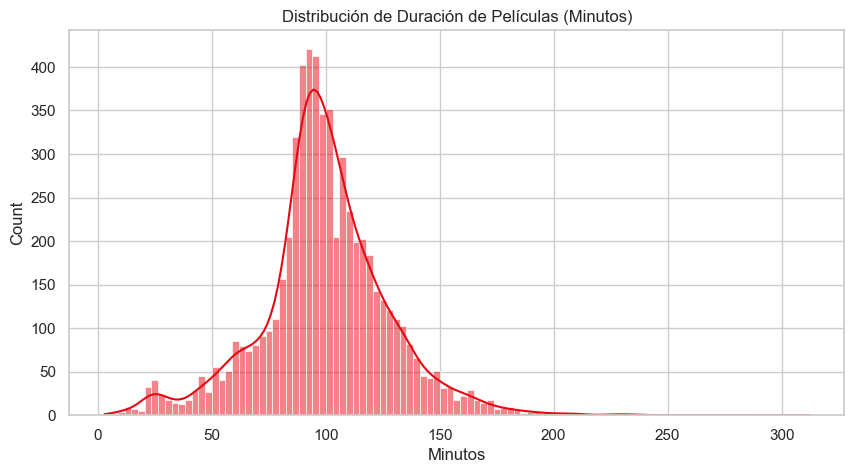

C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\780310386.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='seasons_num', data=tv_shows, palette='Greys_d')


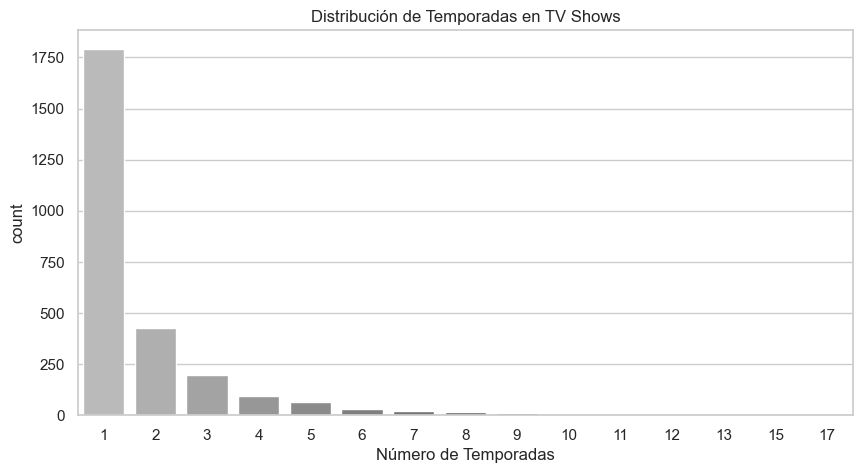

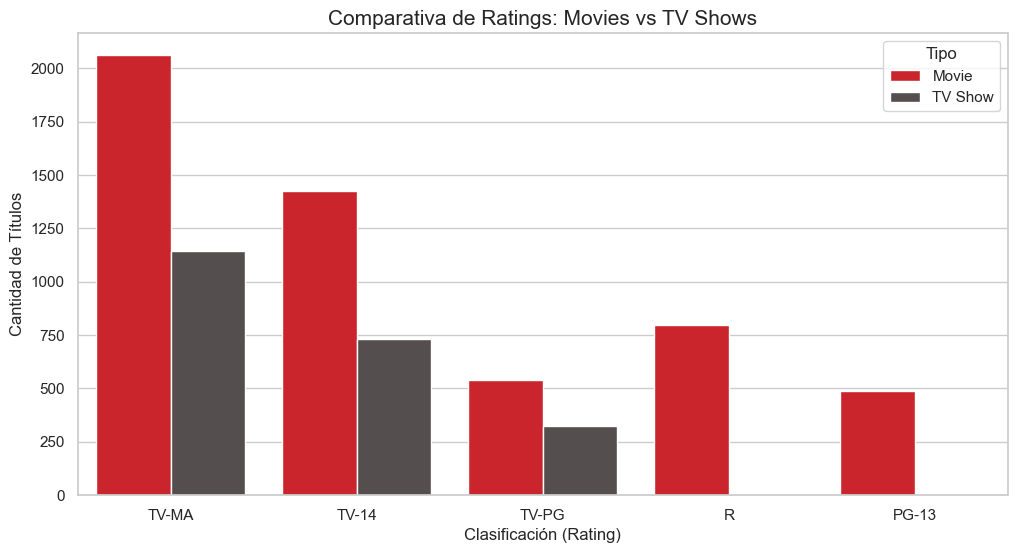

In [11]:
#Comparacion de las series vs peliculas#
def series_vs_peliculas(df):
    # Preparación de datos
    # Separamos las duraciones para que sean números
    movies = df[df['type'] == 'Movie'].copy()
    movies['duration_num'] = movies['duration'].str.replace(' min', '').astype(float)

    tv_shows = df[df['type'] == 'TV Show'].copy()
    tv_shows['seasons_num'] = tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

    # Graficamos la distribución de Películas
    plt.figure(figsize=(10, 5))
    sns.histplot(movies['duration_num'], kde=True, color='#E50914')
    plt.title('Distribución de Duración de Películas (Minutos)')
    plt.xlabel('Minutos')
    plt.show()

    # Graficamos la distribución de Series (Temporadas)
    plt.figure(figsize=(10, 5))
    sns.countplot(x='seasons_num', data=tv_shows, palette='Greys_d')
    plt.title('Distribución de Temporadas en TV Shows')
    plt.xlabel('Número de Temporadas')
    plt.show()

    # Filtramos los ratings más comunes para limpiar la gráfica
    top_ratings = df['rating'].value_counts().head(5).index
    df_rating = df[df['rating'].isin(top_ratings)]

    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_rating, x='rating', hue='type', palette=['#E50914', '#564D4D'], order=top_ratings)

    plt.title('Comparativa de Ratings: Movies vs TV Shows', fontsize=15)
    plt.xlabel('Clasificación (Rating)')
    plt.ylabel('Cantidad de Títulos')
    plt.legend(title='Tipo')
    plt.show()

#Uso 
series_vs_peliculas(df)

C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\2850949312.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\2850949312.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mes'] = df['date_added'].dt.month
C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\2850949312.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

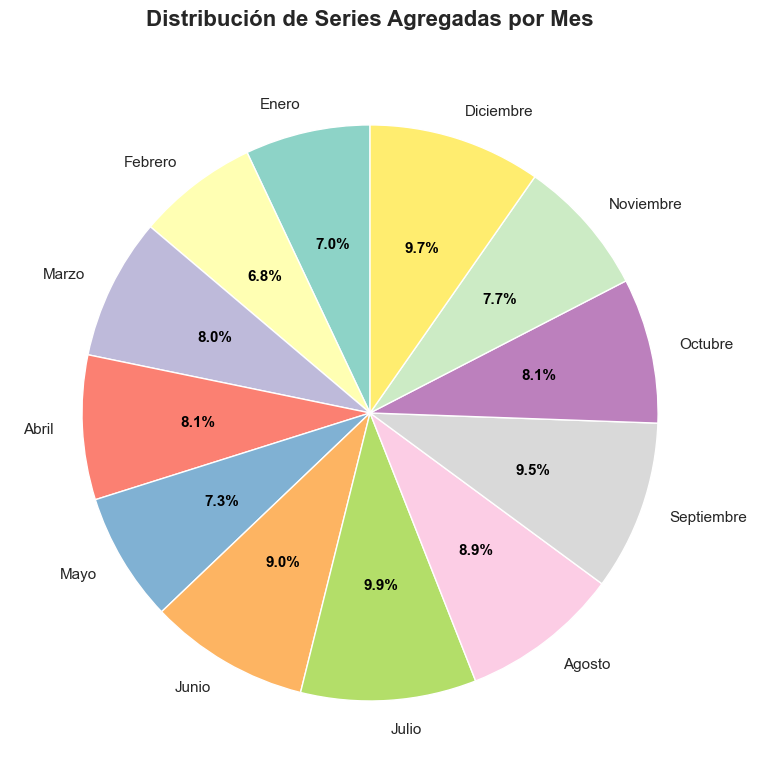

In [12]:
# Cuando es el mejor momento para lanzar una serie de television?#
def date_tvshow(df):
    # Realizamos el Filtro para que sean unicamente las series de Television
    df = filtrar_Tipo(df,2)
    # Covertimos la fecha de salida en datetime para poder realizar calculos#
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['mes'] = df['date_added'].dt.month
    df['mes_nombre'] = df['date_added'].dt.month_name()
    
    # Contamos cuántas series se agregaron por mes
    conteo_mes = df['mes'].value_counts().sort_index()
    
    return df, conteo_mes


def graficar_series_por_mes(conteo_mes):
    # Mapeo de números de mes a nombres en español
    meses_nombres = {
        1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
        7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
    }
    
    # Renombrar índices a nombres de meses
    labels = [meses_nombres.get(mes, f'Mes {mes}') for mes in conteo_mes.index]
    
    # Crear gráfica de pastel
    plt.figure(figsize=(12, 8))
    colores = plt.cm.Set3(range(len(conteo_mes)))
    
    wedges, texts, autotexts = plt.pie(
        conteo_mes.values,
        labels=labels,
        autopct='%1.1f%%',
        colors=colores,
        startangle=90,
        textprops={'fontsize': 11}
    )
    
    # Personalización
    plt.title('Distribución de Series Agregadas por Mes', fontsize=16, fontweight='bold', pad=20)
    
    # Hacer los porcentajes más legibles
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()
# Uso
res = date_tvshow(df)
graficar_series_por_mes(res[1])

C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\3963899953.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


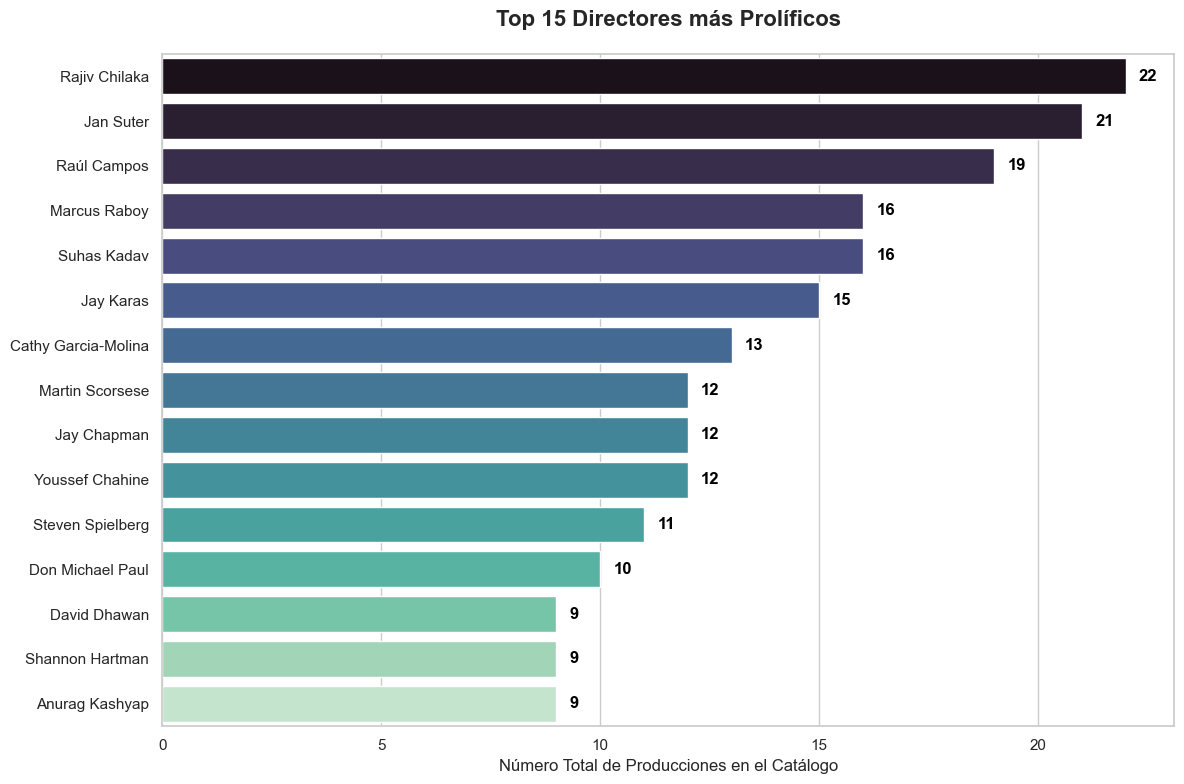

In [14]:
def director_or_cast(df, busqueda):
    # 1: Actores, 2: Directores
    columna = 'cast' if busqueda == 1 else 'director'
    
    # 1. Obtenemos la serie, limpiamos nulos y separamos por comas
    # explode() convierte cada nombre en su propia fila
    personas_series = df[columna].dropna().str.split(',').explode().str.strip()
    
    # Para obtener los ÚNICOS (tu list_search)
    unicos = personas_series.unique()
    
    # Para obtener el CONTEO real de cada persona
    conteo = personas_series.value_counts()
    
    return unicos, conteo

def graficar_top_talento(conteo, busqueda):
    # Definimos el título según lo que estemos analizando
    titulo = "Top 15 Actores más Prolíficos" if busqueda == 1 else "Top 15 Directores más Prolíficos"
    color_map = "rocket" if busqueda == 1 else "mako"

    # Configuramos el tamaño y estilo
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    # Tomamos los primeros 15 resultados del conteo
    top_15 = conteo.head(15)

    # Creamos la gráfica de barras horizontales
    sns.barplot(
        x=top_15.values,      # El número de producciones
        y=top_15.index,       # Los nombres de las personas
        palette=color_map
    )

    # Personalización para el Business Summary
    plt.title(titulo, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Número Total de Producciones en el Catálogo', fontsize=12)
    plt.ylabel('') # Quitamos la etiqueta del eje Y porque los nombres ya son claros
    
    # Añadimos el número exacto al final de cada barra para mayor precisión
    for i, v in enumerate(top_15.values):
        plt.text(v + 0.3, i, str(v), color='black', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()


# Uso:
unicos, top_personas = director_or_cast(df, 2)
graficar_top_talento(top_personas,2)

In [ ]:
# Que tipo de contenido esta disponible en diferentes paises?#
def contenido_disponible(df,tipo):
    # Realizamos un filtro para eliminar los paises extra que aparezca en pais en la B.D. para que solo se tome el primero#
    # df_limpio = df.dropna()
    df = filtrar_Tipo(df,tipo)
    df['first_country'] = df['country'].str.split(',').str[0].str.strip()

    conteo_paises = df['first_country'].value_counts().reset_index()
    conteo_paises.columns = ['Pais', 'Total']
    conteo_paises["Total_log"] = np.log1p(conteo_paises["Total"])

    fig = px.choropleth(
    conteo_paises,
    locations="Pais",
    locationmode='country names',
    color="Total_log",
    hover_name="Pais",
    hover_data= ["Total"],
    color_continuous_scale="Greens", 
    title=f"Contenido Global de {'Peliculas' if tipo == 1 else 'Series de Television'} en Netlix"
    )
    fig.update_geos(
    showcountries=True, 
    countrycolor="Linen",
    showland=True, 
    landcolor="White"
    )
    
    fig.show()

#Uso
contenido_disponible(df,1)

C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\587145975.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['first_country'] = df['country'].str.split(',').str[0].str.strip()
C:\Users\Isaia\AppData\Local\Temp\ipykernel_24152\587145975.py:12: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
